In [222]:
!pip install lxml -q
!pip install pandas scikit-learn numpy xlrd -q


In [223]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.style as style
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from datetime import datetime
import seaborn as sns
import requests

In [224]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [225]:
df=pd.read_excel('/content/drive/MyDrive/CoderHouse Juan Guzman/DATA SCIENCE II/Base_Datos_2024_91.xlsx')
df.head()

,Código,Tipo_documento,Num_documento,Género,SIM,Fec_Ingreso,Edad,Zonal - Remitido_por,Dirección,Teléfono,...,Eps,Fecha remision,Localidad,Etnia,Gra_Estudio,Ori_Sexual,Discapcidad,Institucion,Regimen,trastorno_mental
0,23763,Tarjeta de Identidad,112,Femenino,1761393349,09/04/2019,0,Usaquen,CLL 130 No.7 B BIS 48,3123404917-3118890339,...,NaN,25/02/2019,Usaquen,Ninguna,Secundaria Incompleta,No,Ninguna,AGUSTIN FERNANDEZ,R. Contributivo,No
1,23909,Tarjeta de Identidad,230,Masculino,1761442924,28/06/2019,0,Usaquen,NO REPORTA,3195783660,...,NaN,11/04/2019 12:0,Usaquen,Ninguna,Secundaria Incompleta,No,Ninguna,NO REPORTA,R. Contributivo,No
2,24024,Cédula de Ciudadania,330,Masculino,137115156,20/05/2019,0,Kennedy,calle 7 # 94 - 78,3138873546 - 4494607,...,NaN,17/03/2019,Kennedy,Ninguna,Secundaria Incompleta,No,Ninguna,LICEO EL CASTILLO,R. Contributivo,No
3,24137,Registro Civil,437,Femenino,14753535,27/05/2019,0,Fontibon,CRA 113 A # 16-34,3217043262-3197162256,...,NaN,28/04/2019 12:0,Fontibon,Ninguna,Antes de Primaria,No,Ninguna,ALADINO,No tienen,Si
4,24449,Tarjeta de Identidad,712,Masculino,14578064,12/07/2019,0,Puente Aranda,calle 74 # 108 - 75,3106953256,...,NaN,14/03/2019,Puente Aranda,Ninguna,Secundaria Incompleta,No,Ninguna,INFODEC,R. Subsidiado,No


In [226]:
url = "https://github.com/MAX181818/session/raw/main/Base_Datos_2024_91.xlsx"
response = requests.get(url)

with open("Base_Datos_2024_91.xlsx", "wb") as f:
    f.write(response.content)

In [227]:
df = pd.read_excel("Base_Datos_2024_91.xlsx")
df.head()

,Código,Tipo_documento,Num_documento,Género,SIM,Fec_Ingreso,Edad,Zonal - Remitido_por,Dirección,Teléfono,...,Eps,Fecha remision,Localidad,Etnia,Gra_Estudio,Ori_Sexual,Discapcidad,Institucion,Regimen,trastorno_mental
0,23763,Tarjeta de Identidad,112,Femenino,1761393349,09/04/2019,0,Usaquen,CLL 130 No.7 B BIS 48,3123404917-3118890339,...,NaN,25/02/2019,Usaquen,Ninguna,Secundaria Incompleta,No,Ninguna,AGUSTIN FERNANDEZ,R. Contributivo,No
1,23909,Tarjeta de Identidad,230,Masculino,1761442924,28/06/2019,0,Usaquen,NO REPORTA,3195783660,...,NaN,11/04/2019 12:0,Usaquen,Ninguna,Secundaria Incompleta,No,Ninguna,NO REPORTA,R. Contributivo,No
2,24024,Cédula de Ciudadania,330,Masculino,137115156,20/05/2019,0,Kennedy,calle 7 # 94 - 78,3138873546 - 4494607,...,NaN,17/03/2019,Kennedy,Ninguna,Secundaria Incompleta,No,Ninguna,LICEO EL CASTILLO,R. Contributivo,No
3,24137,Registro Civil,437,Femenino,14753535,27/05/2019,0,Fontibon,CRA 113 A # 16-34,3217043262-3197162256,...,NaN,28/04/2019 12:0,Fontibon,Ninguna,Antes de Primaria,No,Ninguna,ALADINO,No tienen,No
4,24449,Tarjeta de Identidad,712,Masculino,14578064,12/07/2019,0,Puente Aranda,calle 74 # 108 - 75,3106953256,...,NaN,14/03/2019,Puente Aranda,Ninguna,Secundaria Incompleta,No,Ninguna,INFODEC,R. Subsidiado,No


## Abstracto con motivación y audiencia


Este conjunto de datos contiene información demográfica y diagnósticos de salud mental de niños que han sido víctimas de abuso sexual. Incluye datos personales (Se elimino el nombre de los pacientes y la identificacion de cada uno de ellos se llevo a un Id de 0 hasta el numero de filas totales de la base de datos), así como un registro sobre la presencia de algún trastorno mental. Este conjunto de datos es fundamental para analizar las posibles correlaciones entre el abuso sexual infantil y el desarrollo de enfermedades mentales. La información demográfica permite examinar cómo factores como la edad y la ubicación pueden influir en la prevalencia de trastornos mentales entre las víctimas. Este análisis podría contribuir a la creación de políticas y programas de apoyo más eficaces para ayudar a estas personas.


## Preguntas y Hipotesis

Se debe empezar desde la base de que los niños que se atienden en la fundación llegaron a la misma por denuncias ante el institulo de bienestar familiar, por lo que en principio nuestra base de datos se constituye de niños en las que sus responsables llevan un proceso con el gobieron de restablecimiento de derechos

Pregunta: ¿La ubicación geográfica tiene un efecto en la salud mental de los niños que se atienden en la fundación?
Hipótesis: Se sugiere que los niños que viven en áreas con menos recursos podrían tener una mayor probabilidad de desarrollar trastornos mentales, ya que a menudo enfrentan barreras en el acceso a servicios de salud y apoyo social.

Pregunta: ¿La edad influye en la probabilidad de que los niños que se atienden en la fundación desarrollen trastornos mentales?
Hipótesis: Los niños más pequeños podrían ser más vulnerables a los trastornos mentales, ya que tienen menos herramientas para enfrentar y expresar las emociones relacionadas con experiencias traumáticas.

Pregunta: ¿La discapacidad de los pacientes influye en la probabilidad de que los niños que se atienden en la fundación desarrollen trastornos mentales?
Hipótesis: Los niños que presentan discapacidades mentales, intelectuales, sensoriables, auditivas o visuales podrían ser más vulnerables a los trastornos mentales que acarrea el abuso sexual infantil, ya que tienen menos herramientas para enfrentar y expresar las emociones relacionadas con experiencias traumáticas.

 Las instituciones que no cuentan con suficientes recursos o personal capacitado podrían tener una mayor incidencia de casos de abuso sexual, lo que a su vez podría contribuir a un aumento en los problemas de salud mental entre los niños que allí se encuentran.

 ## Objetivo

 Encontrar patrones de comportamientos identificables que predisponen a una a persona a sufrir de trastornos mental
 Y generar un modelo que prediga dicha tendencia

 ## Contexto

 Los datos de recopilaron de una Fundación sin animo de lucro, la cual atiende niños a los cuales se le vulneraron sus derechos y se les hace una entrevista para revisar su estado mental.

 ## Contexto Analitico

'Género': Masculino o Femenino
'Edad': Edad del paciente
'Zonal - Remitido_por': Centro de emergencia que remite el paciente
'Dirección': Direccion del paciente
'Localidad': Area donde reside el paciente
'Etnia': Grupo al que pertenece el paciente
'Gra_Estudio': Nivel de estudio que alcanzo el paciente
'Ori_Sexual': Orientacion sexual del paciente
'Institucion': Institucion donde vive o es atentida a la familia
'Eps': Entidad Promotora de Salud
'Discapacidad': Discapacidad que presenta el paciente
'Regimen': Regimen de salud a la que esta afiliado el paciente
'trastorno_mental': Resultado del examen clinico por parte de las terapeutas de la Fundación
  

## Análisis exploratorio de datos (EDA)

In [228]:
# Columnas con porcentaje de nulos
pd.set_option('display.max_rows', None)  # or 1000

In [229]:
df.isnull().sum()

,0
Código,0
Tipo_documento,0
Num_documento,0
Género,11
SIM,25
Fec_Ingreso,0
Edad,0
Zonal - Remitido_por,0
Dirección,1
Teléfono,114


In [230]:
df.shape[0]

10073

In [231]:
serie=(df.isnull().sum()/df.shape[0])*100
serie

,0
Código,0.000000
Tipo_documento,0.000000
Num_documento,0.000000
Género,0.109203
SIM,0.248188
Fec_Ingreso,0.000000
Edad,0.000000
Zonal - Remitido_por,0.000000
Dirección,0.009928
Teléfono,1.131738


In [232]:
serie=serie.sort_values(ascending=False)
serie= serie[serie>0]
serie

,0
Eps,12.885933
Localidad,9.411298
Terapeuta,8.140574
Institucion,1.369999
Teléfono,1.131738
SIM,0.248188
Defensor,0.148913
Género,0.109203
Fecha remision,0.039710
Responsable,0.009928


<Axes: >

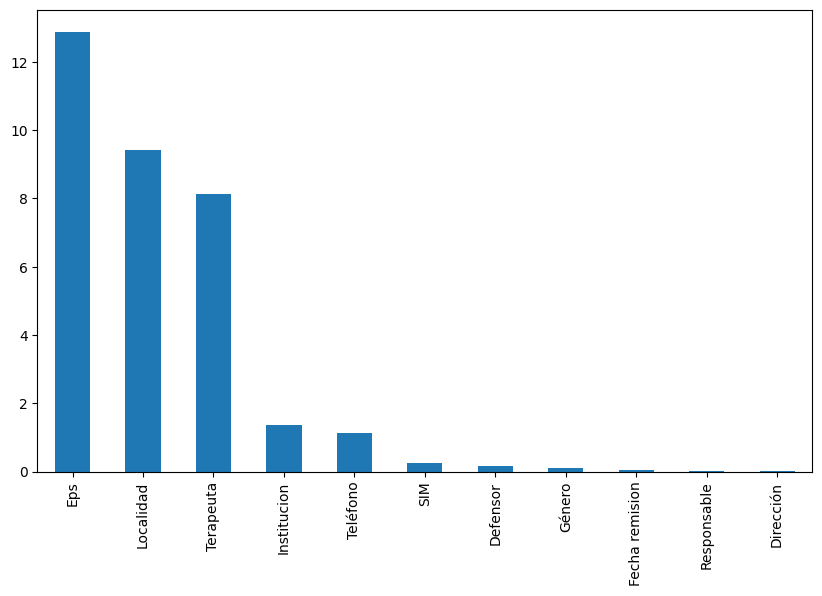

In [233]:
# Graficamente
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
serie.plot(kind='bar')

In [234]:
pip install missingno

<Axes: >

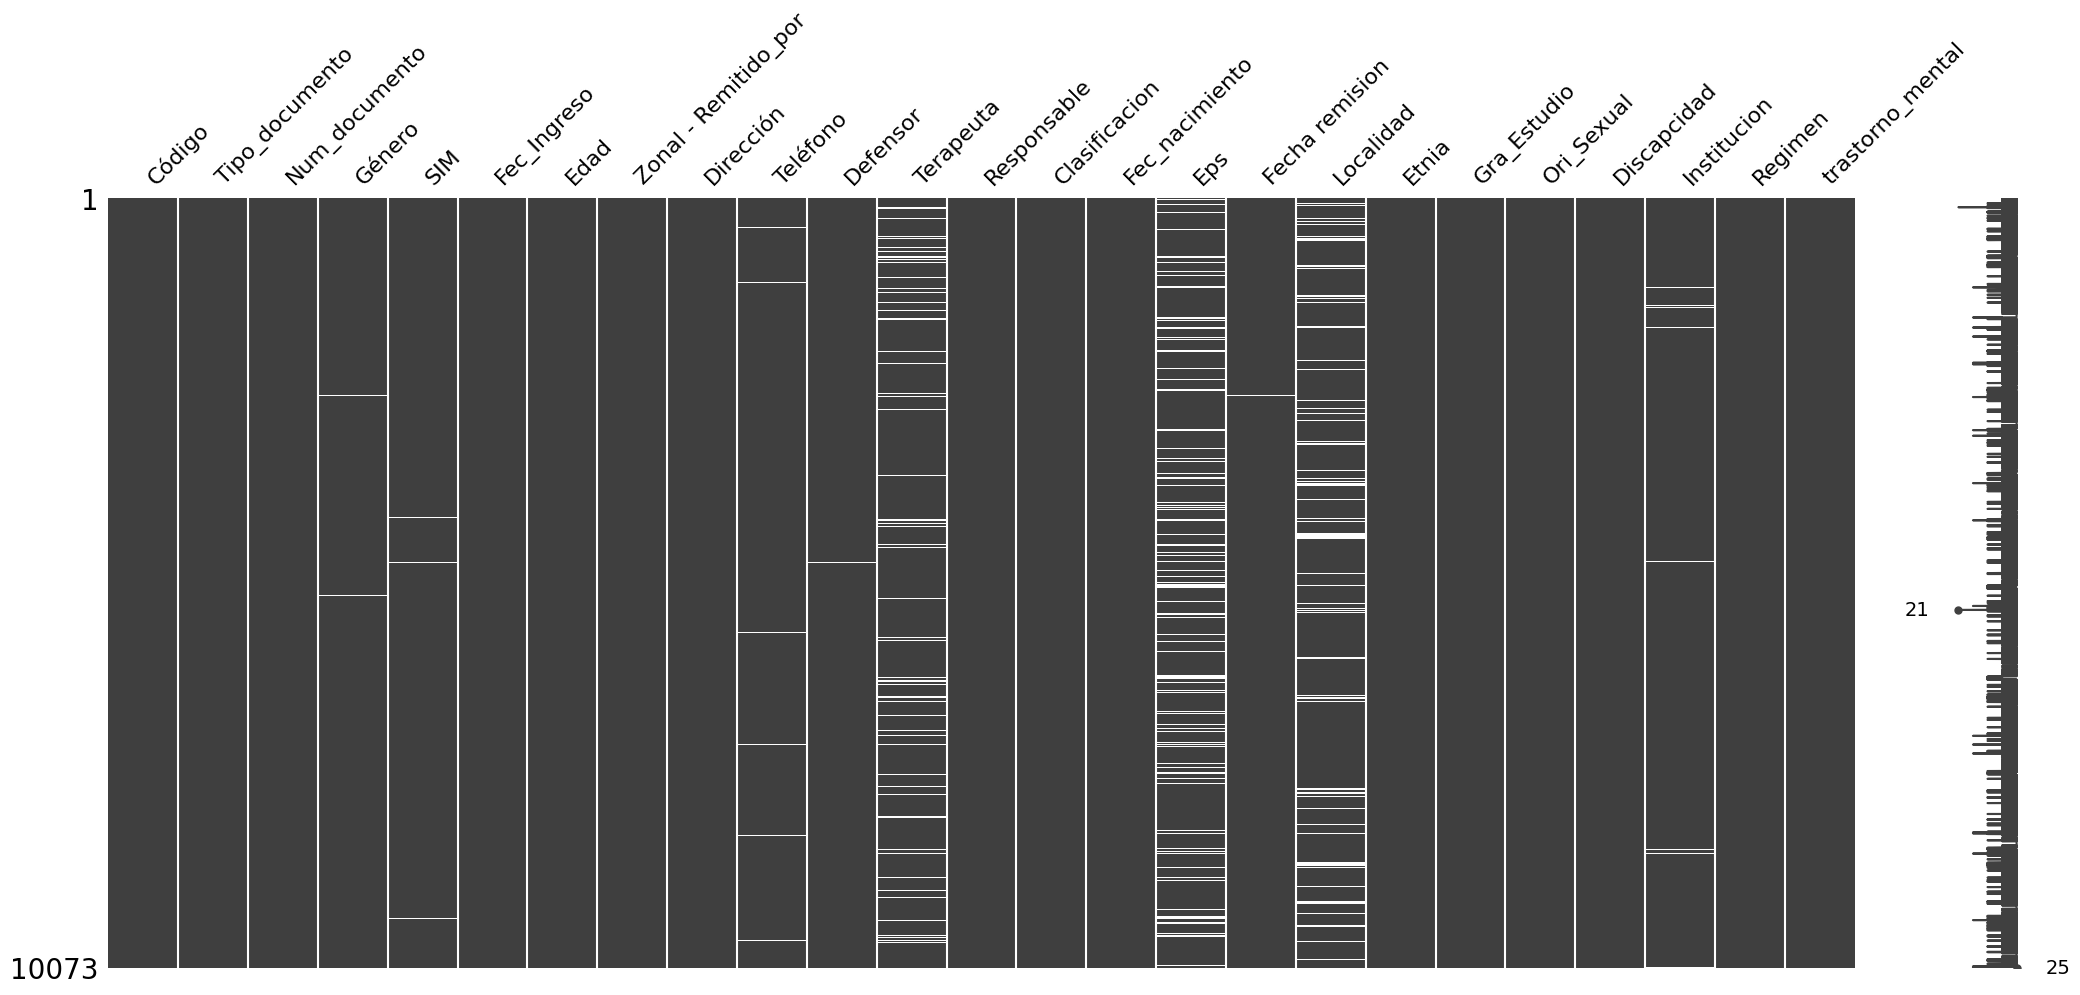

In [235]:
import missingno as msno
msno.matrix(df)

<Axes: >

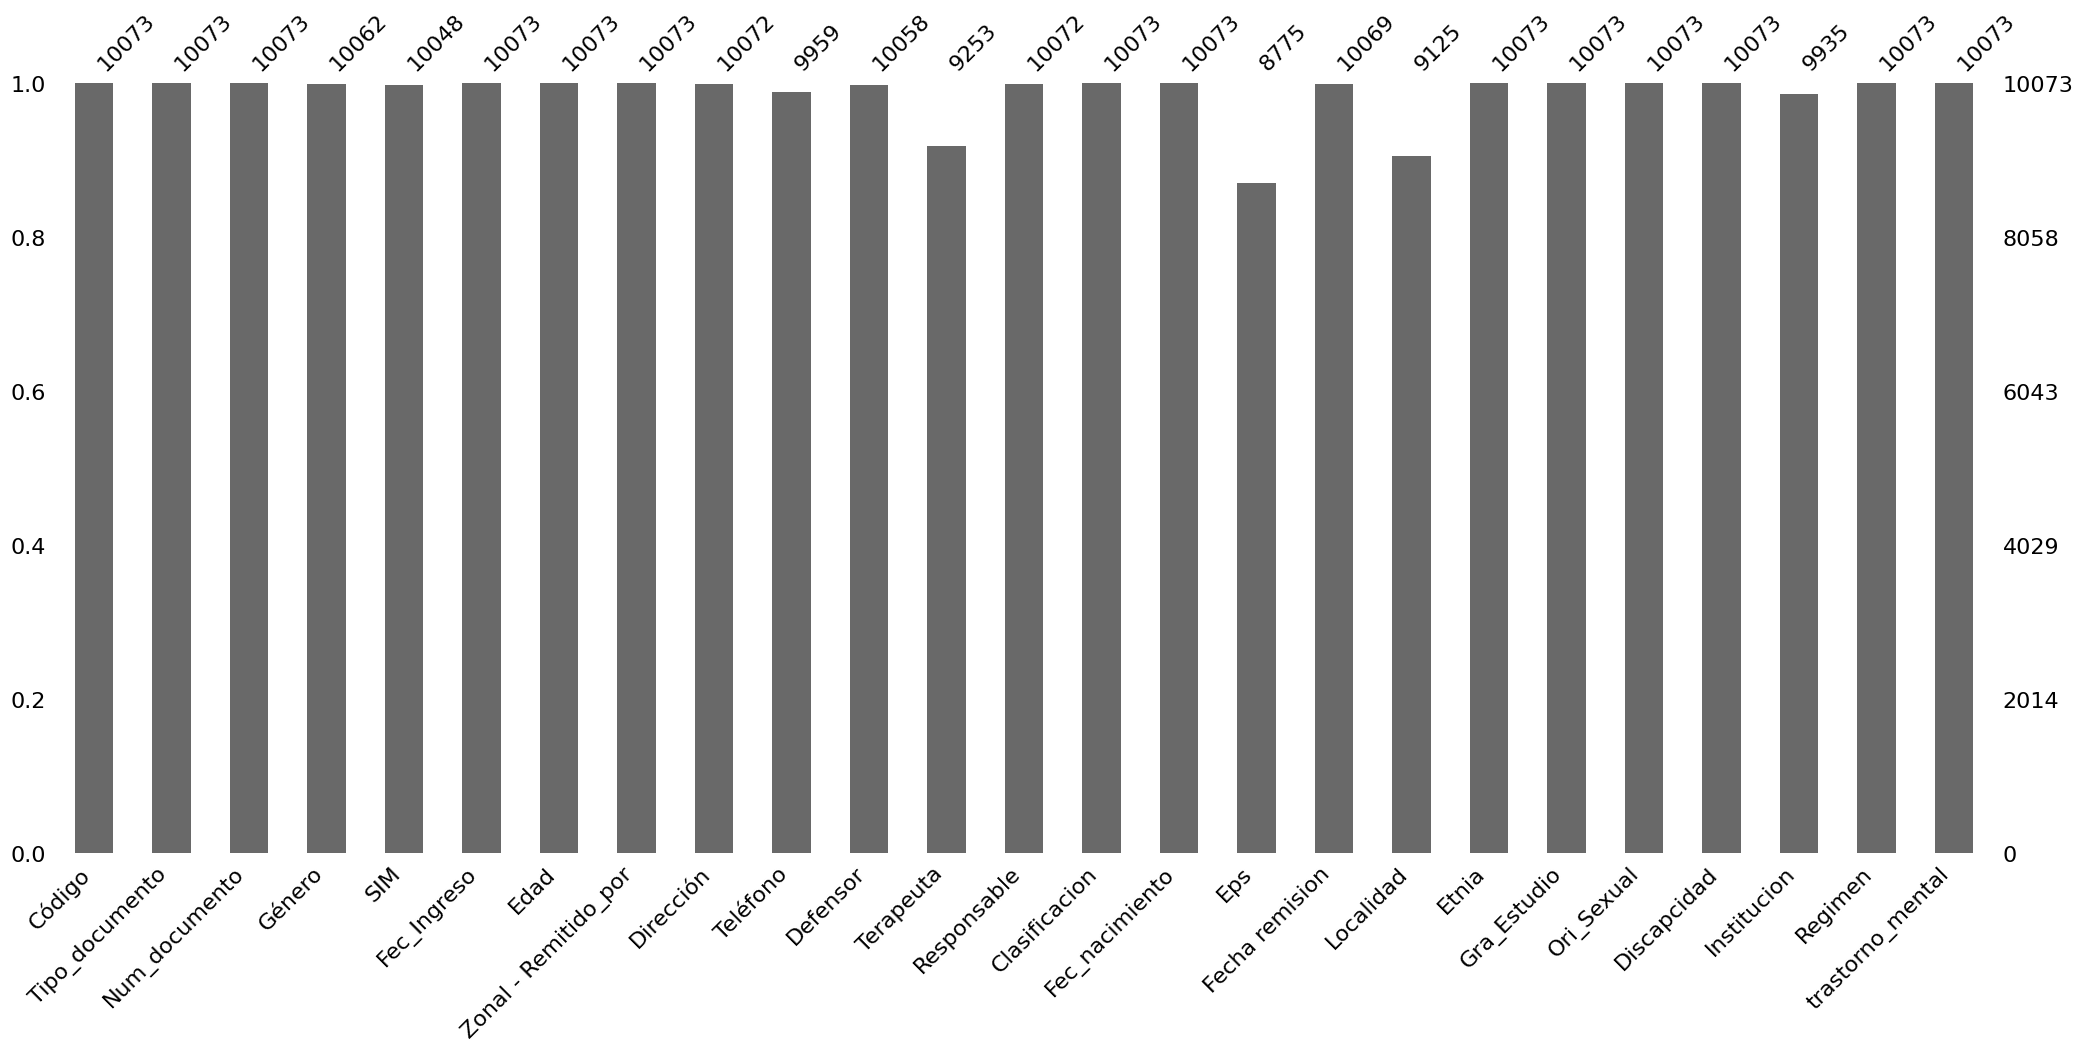

In [236]:
msno.bar(df)

<Axes: >

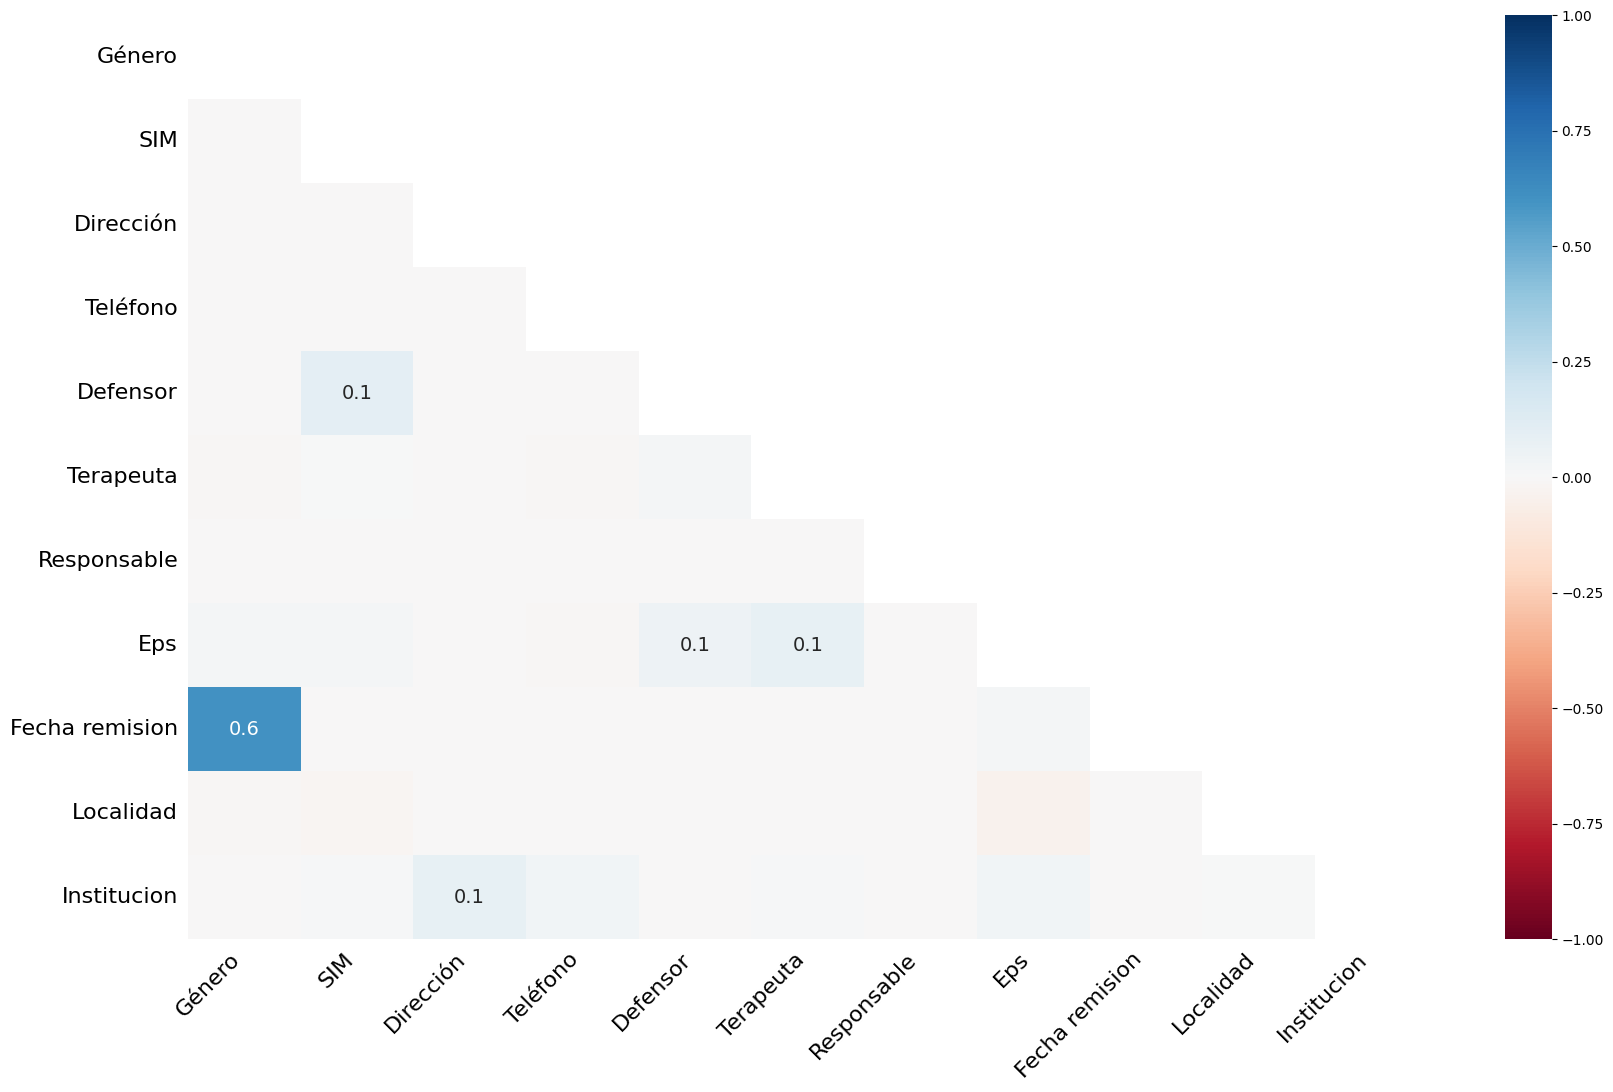

In [237]:
msno.heatmap(df)

<Axes: >

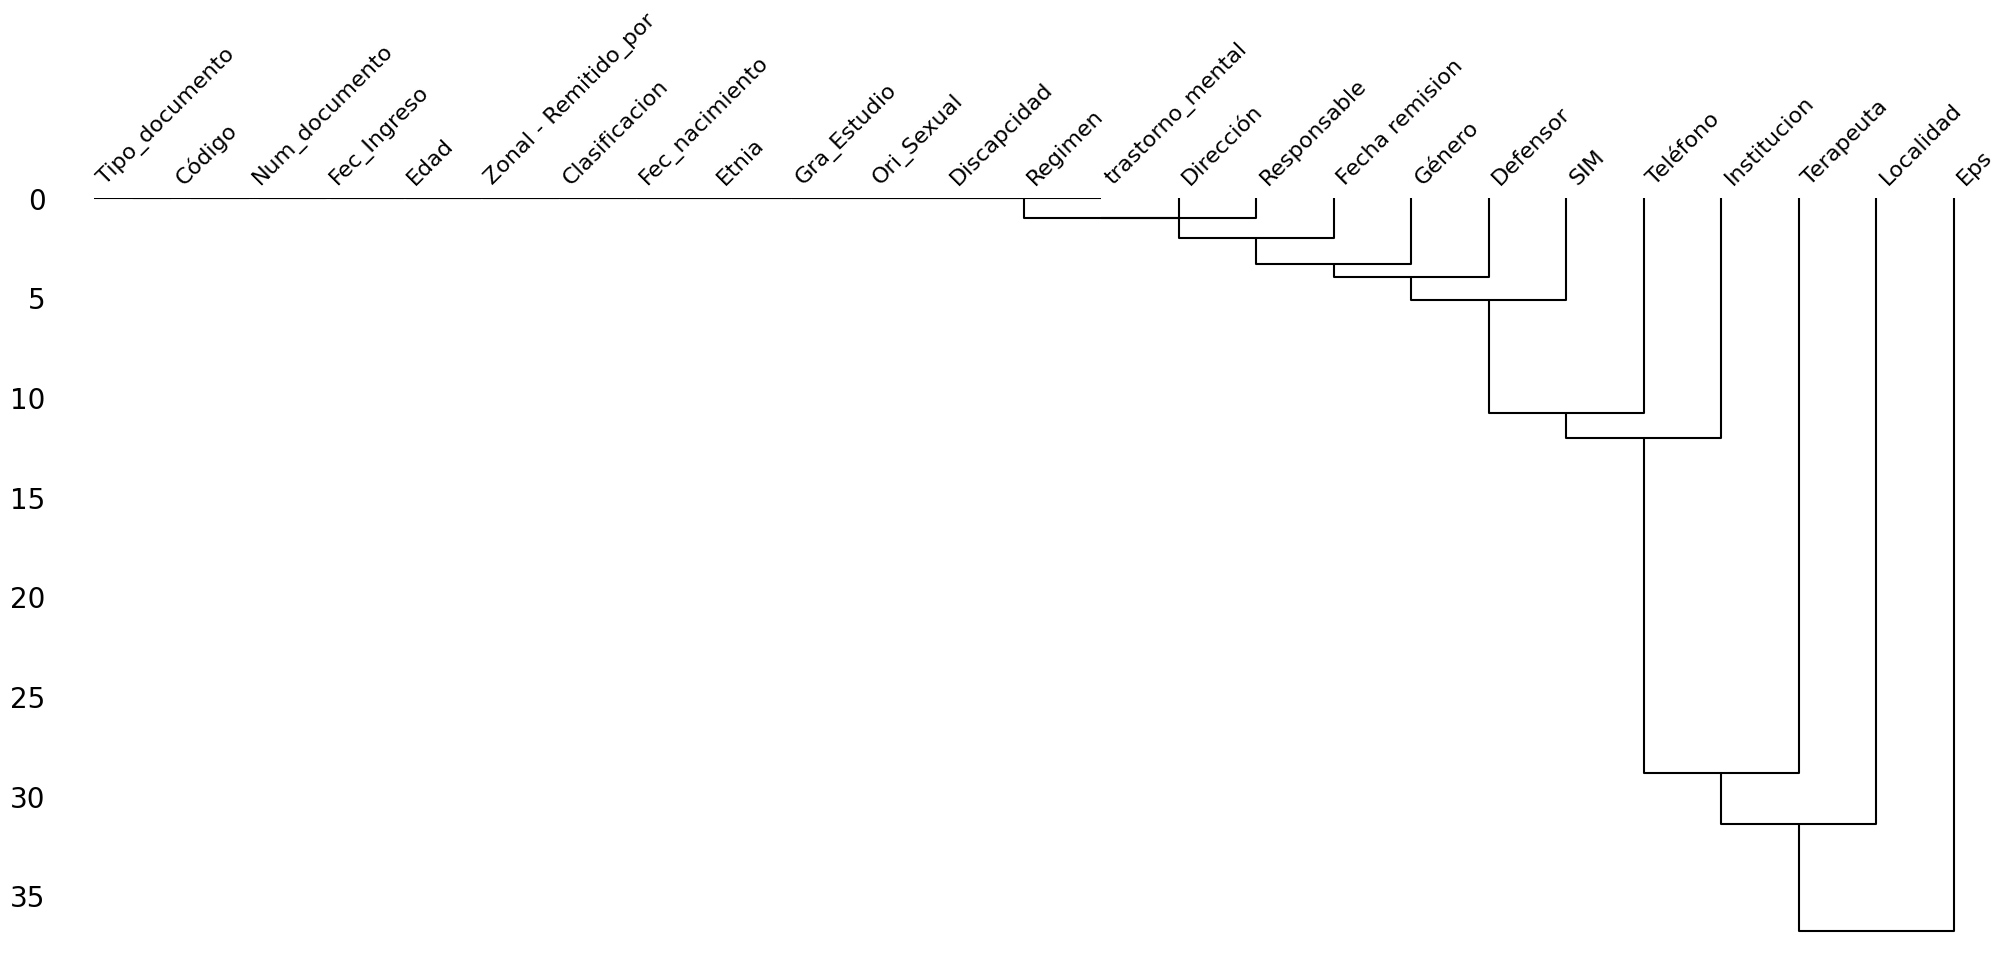

In [238]:
msno.dendrogram(df)

Basado en el anterior analisis se tomaria la decision de eliminar la columna "EPS" por tener un porcentaje en el grafico .bar de faltantes tan alto, pero no se hara debido a que se considera que en el analisis cualitativo puede servir para entender que niños con posibles transtornos mentales pertencen a EPS (Entidades promotoras de Salud) que no promocionaron correctamente la salud mental de sus afiliados


In [239]:
col_del=[] # Columnas a borrar que no aportan
col_inter= [] # Columnas a interpolar
col_cat= ['Eps','Localidad','Terapeuta','Institucion','Teléfono','Género','Defensor','Fecha remision','Responsable','SIM','Dirección'] # Columnas cateogoricas

# Llenar con categoria desconocido

In [240]:
for i in col_cat: # Reemplazar los vacios por Desconocido
  df[i] = df[i].fillna('Ninguno')

## # Exploratory Data Analysis (EDA)
El proceso que se realizara es el siguiente

1.   Verificacion de datos iniciales
2.   Datos nulos y datos duplicados
3.   Graficos univariados
4.   Graficos multivariados
5.   Outliers
6.   Decisiones a realizar

## 1. Verificacion de datos iniciales

In [241]:
df.head()

,Código,Tipo_documento,Num_documento,Género,SIM,Fec_Ingreso,Edad,Zonal - Remitido_por,Dirección,Teléfono,...,Eps,Fecha remision,Localidad,Etnia,Gra_Estudio,Ori_Sexual,Discapcidad,Institucion,Regimen,trastorno_mental
0,23763,Tarjeta de Identidad,112,Femenino,1761393349,09/04/2019,0,Usaquen,CLL 130 No.7 B BIS 48,3123404917-3118890339,...,Ninguno,25/02/2019,Usaquen,Ninguna,Secundaria Incompleta,No,Ninguna,AGUSTIN FERNANDEZ,R. Contributivo,No
1,23909,Tarjeta de Identidad,230,Masculino,1761442924,28/06/2019,0,Usaquen,NO REPORTA,3195783660,...,Ninguno,11/04/2019 12:0,Usaquen,Ninguna,Secundaria Incompleta,No,Ninguna,NO REPORTA,R. Contributivo,No
2,24024,Cédula de Ciudadania,330,Masculino,137115156,20/05/2019,0,Kennedy,calle 7 # 94 - 78,3138873546 - 4494607,...,Ninguno,17/03/2019,Kennedy,Ninguna,Secundaria Incompleta,No,Ninguna,LICEO EL CASTILLO,R. Contributivo,No
3,24137,Registro Civil,437,Femenino,14753535,27/05/2019,0,Fontibon,CRA 113 A # 16-34,3217043262-3197162256,...,Ninguno,28/04/2019 12:0,Fontibon,Ninguna,Antes de Primaria,No,Ninguna,ALADINO,No tienen,No
4,24449,Tarjeta de Identidad,712,Masculino,14578064,12/07/2019,0,Puente Aranda,calle 74 # 108 - 75,3106953256,...,Ninguno,14/03/2019,Puente Aranda,Ninguna,Secundaria Incompleta,No,Ninguna,INFODEC,R. Subsidiado,No


In [242]:
df.tail()


,Código,Tipo_documento,Num_documento,Género,SIM,Fec_Ingreso,Edad,Zonal - Remitido_por,Dirección,Teléfono,...,Eps,Fecha remision,Localidad,Etnia,Gra_Estudio,Ori_Sexual,Discapcidad,Institucion,Regimen,trastorno_mental
10068,33212,Cédula de Ciudadania,8969,Femenino,14712819,19/12/2023,41,Regional Bogota,Calle # 127 # 87 # 87 24,3174532412(MADRE SUSTITUTA)3125880491(RED),...,CAPITAL SALUD,14/12/2023,Otros,Ninguna,Educación Especial,No,Ninguna,DESESCOLARIZADA,R. Subsidiado,No
10069,25999,Tarjeta de Identidad,2114,Femenino,1761579031,17/02/2020,44,Suba,Cra 149c 3142b-41,3147487143,...,Cosalud,28/08/2019,Usaquen,Ninguna,Secundaria Incompleta,No,Ninguna,Actualmente no esta estudiando hizo hasta 5,R. Subsidiado,Si
10070,27934,Tarjeta de Identidad,3890,Femenino,140127891,13/11/2020,0,Bosa,Carrera # 88 C BIS # 50 # 50 23 SUR,3145314136,...,Ninguno,06/11/2020,Bosa,Ninguna,Antes de Primaria,No,Ninguna,Colegio Jaime Garzon,R. Contributivo,Si
10071,23902,Tarjeta de Identidad,224,Masculino,13980350,16/04/2019,16,Puente Aranda,CRA 88 C No.34 33,2933250-3133414413-3112885323-3143329765,...,Ninguno,4/02/2019,Puente Aranda,Ninguna,Secundaria Incompleta,No,Ninguna,JOSE FRANCISCO SOCARRAS,R. Contributivo,No
10072,25105,Tarjeta de Identidad,1281,Masculino,13982481,11/10/2019,16,Fontibon,Calle 14b # 119a - 20,3053505010,...,Ninguno,16/07/2019 12:0,Puente Aranda,Ninguna,Secundaria Incompleta,No,Ninguna,COLEGIO RAMON B. JIMENO,R. Contributivo,Si


In [243]:
#Antes que todo se protege el numero de documento de las victimas
df = df.drop_duplicates(subset='Num_documento', keep='first')
try:
    df.drop(columns=['Tipo_documento'],inplace=True)
    df['Num_documento'] = range(1, len(df) + 1)
    print('Proceso exitoso')
except:
    print('Ya fue eliminado el tipo de documento y cambiado el numero de documento de cada NNA')

Proceso exitoso


In [244]:
print(f"Las dimensiones del data set son {df.shape[0]} filas y {df.shape[1]} columnas")

Las dimensiones del data set son 10073 filas y 24 columnas


In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10073 entries, 0 to 10072
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Código                10073 non-null  int64 
 1   Num_documento         10073 non-null  int64 
 2   Género                10073 non-null  object
 3   SIM                   10073 non-null  object
 4   Fec_Ingreso           10073 non-null  object
 5   Edad                  10073 non-null  int64 
 6   Zonal - Remitido_por  10073 non-null  object
 7   Dirección             10073 non-null  object
 8   Teléfono              10073 non-null  object
 9   Defensor              10073 non-null  object
 10  Terapeuta             10073 non-null  object
 11  Responsable           10073 non-null  object
 12  Clasificacion         10073 non-null  object
 13  Fec_nacimiento        10073 non-null  object
 14  Eps                   10073 non-null  object
 15  Fecha remision        10073 non-null

In [246]:
df.count()

,0
Código,10073
Num_documento,10073
Género,10073
SIM,10073
Fec_Ingreso,10073
Edad,10073
Zonal - Remitido_por,10073
Dirección,10073
Teléfono,10073
Defensor,10073


In [247]:
type(df)

pandas.core.frame.DataFrame

Insights

*   notiene nulos
*   Solo hay 3 variables Int64 y el resto son object

# Estadísticas descriptivas

In [248]:
df.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
Código,10073.0,29098.3,3074.0,23638.0,26481.0,29148.0,31755.0,34354.0
Num_documento,10073.0,5037.0,2908.0,1.0,2519.0,5037.0,7555.0,10073.0
Edad,10073.0,11.4,4.1,0.0,9.0,12.0,15.0,44.0


<ipython-input-249-76130721d734>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  distplot(df.Edad, hist=True)


<Axes: xlabel='Edad', ylabel='Density'>

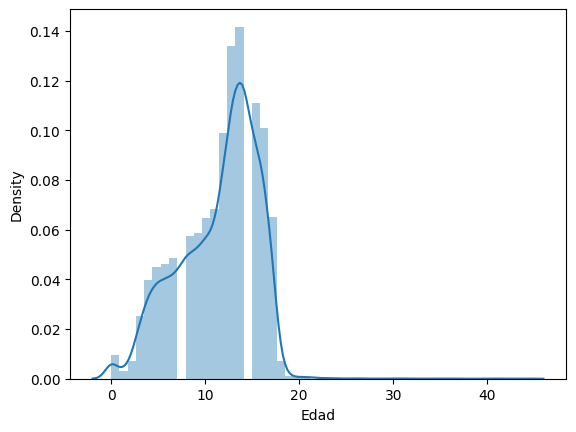

In [249]:
#Histograma
from seaborn import distplot
distplot(df.Edad, hist=True)

Analicemos esas puntas de la edad

<Figure size 1000x600 with 0 Axes>

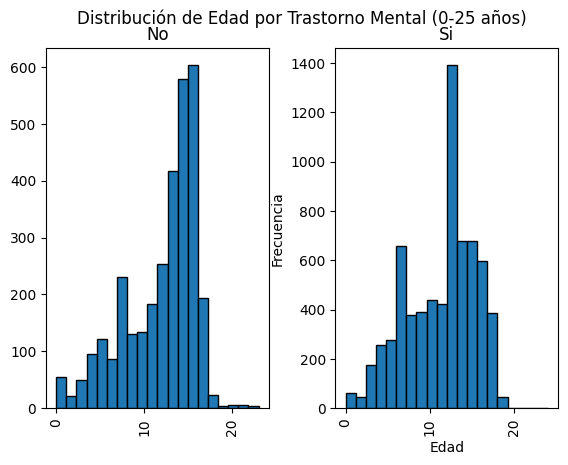

In [250]:
plt.figure(figsize=(10, 6))
df_filtered = df[df['Edad'] <= 25]
df_filtered['Edad'].hist(by=df_filtered['trastorno_mental'], bins=20, edgecolor='black')
plt.suptitle('Distribución de Edad por Trastorno Mental (0-25 años)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

<Axes: ylabel='Edad'>

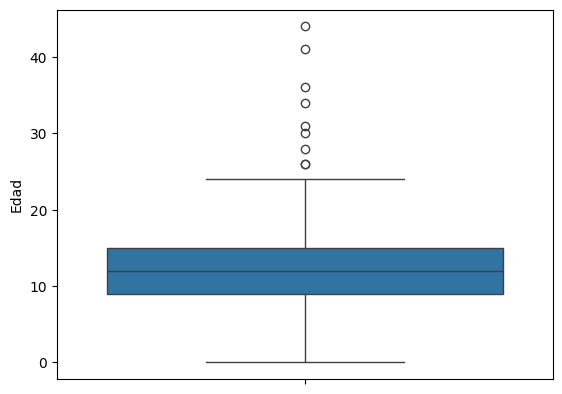

In [251]:
sns.boxplot(df["Edad"])

Estas son las columnas disponibles

In [252]:
df.columns

Index(['Código', 'Num_documento', 'Género', 'SIM', 'Fec_Ingreso', 'Edad',
       'Zonal - Remitido_por', 'Dirección', 'Teléfono', 'Defensor',
       'Terapeuta', 'Responsable', 'Clasificacion', 'Fec_nacimiento', 'Eps',
       'Fecha remision', 'Localidad', 'Etnia', 'Gra_Estudio', 'Ori_Sexual',
       'Discapcidad', 'Institucion', 'Regimen', 'trastorno_mental'],
      dtype='object')

Distribución de Edad por Trastornos Mentales, Se puede ver que la poblacion de mayor enfermedad mental roza los 13 años, por lo tanto, se deben hacer planes para mitirgar este riesgo de abuso sexual para niños que estan mas que todo en esa edad

<Figure size 1000x600 with 0 Axes>

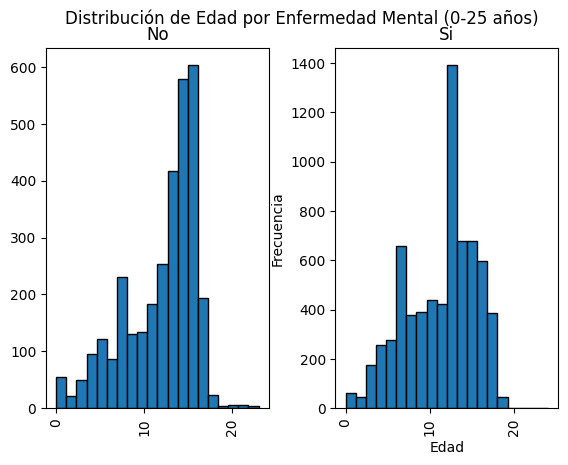

In [253]:
plt.figure(figsize=(10, 6))
df_filtered = df[df['Edad'] <= 25]
df_filtered['Edad'].hist(by=df_filtered['trastorno_mental'], bins=20, edgecolor='black')
plt.suptitle('Distribución de Edad por Enfermedad Mental (0-25 años)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


Casos por Localidad, podemos ver que nos hace falta identificar la localidad de muchos casos, por lo tanto, podemos decir que la localidad de Usaquen, rafael uribel y Engativa es quien mas enfermedades mentales tiene

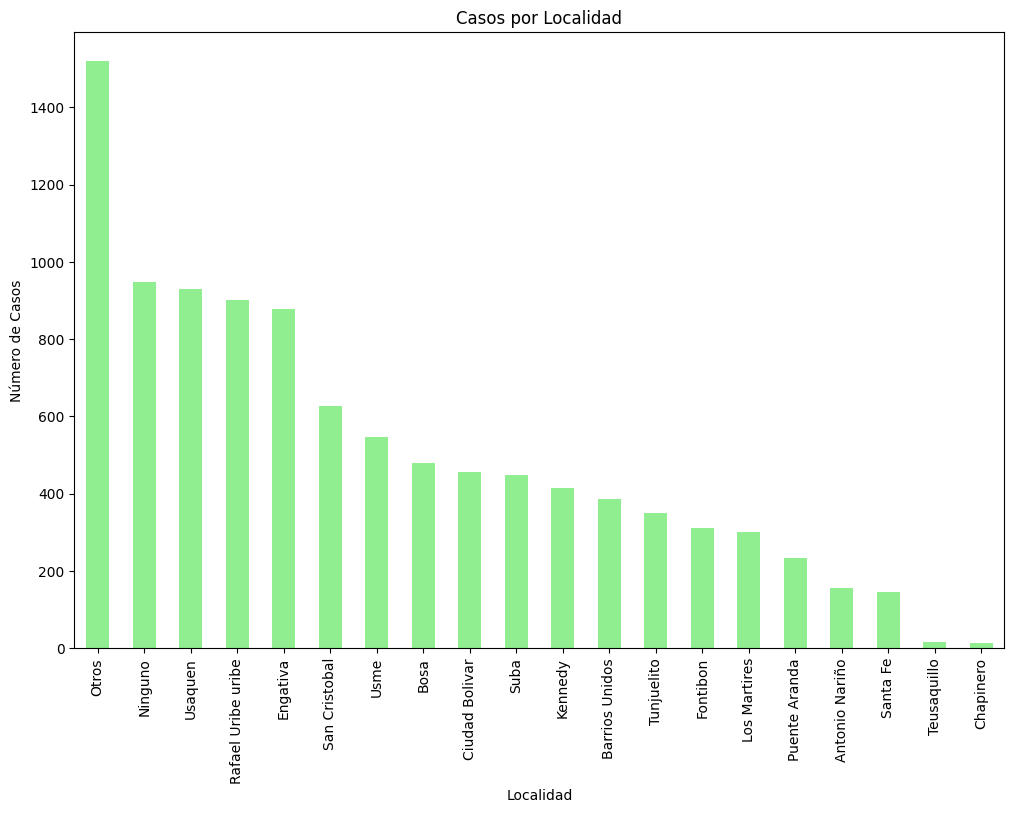

In [254]:
plt.figure(figsize=(12, 8))
df = df[df['Edad'] <= 25]
df['Localidad'].value_counts().plot(kind='bar', color='lightgreen')
plt.title('Casos por Localidad')
plt.xlabel('Localidad')
plt.ylabel('Número de Casos')
plt.xticks(rotation=90)
plt.show()


Boxplot de Edad por Enfermedad Mental, podemos ver que nuestra media de casos esta cerca a los 12 o 13 años lo cual tiene sentido con respecto a las anteriores graficas mostradas

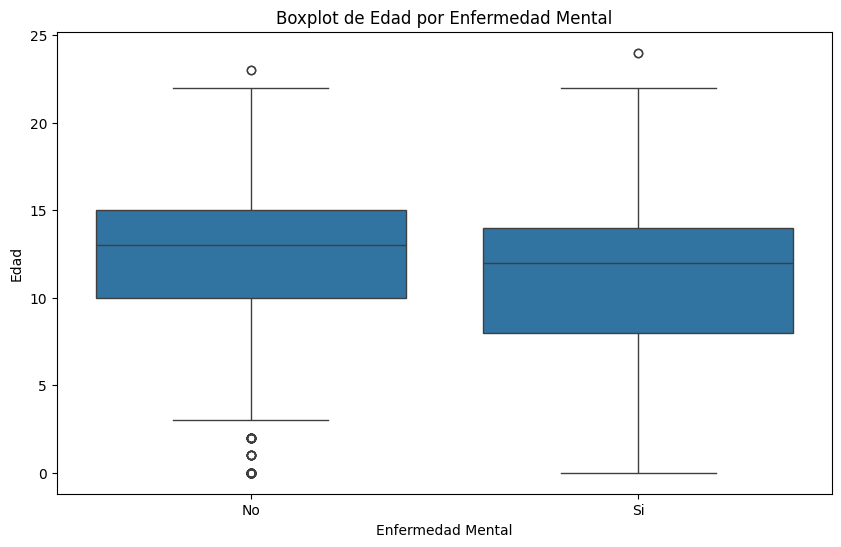

In [255]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='trastorno_mental', y='Edad', data=df)
plt.title('Boxplot de Edad por Enfermedad Mental')
plt.xlabel('Enfermedad Mental')
plt.ylabel('Edad')
plt.show()


Indice de correlacion entre variables numericas

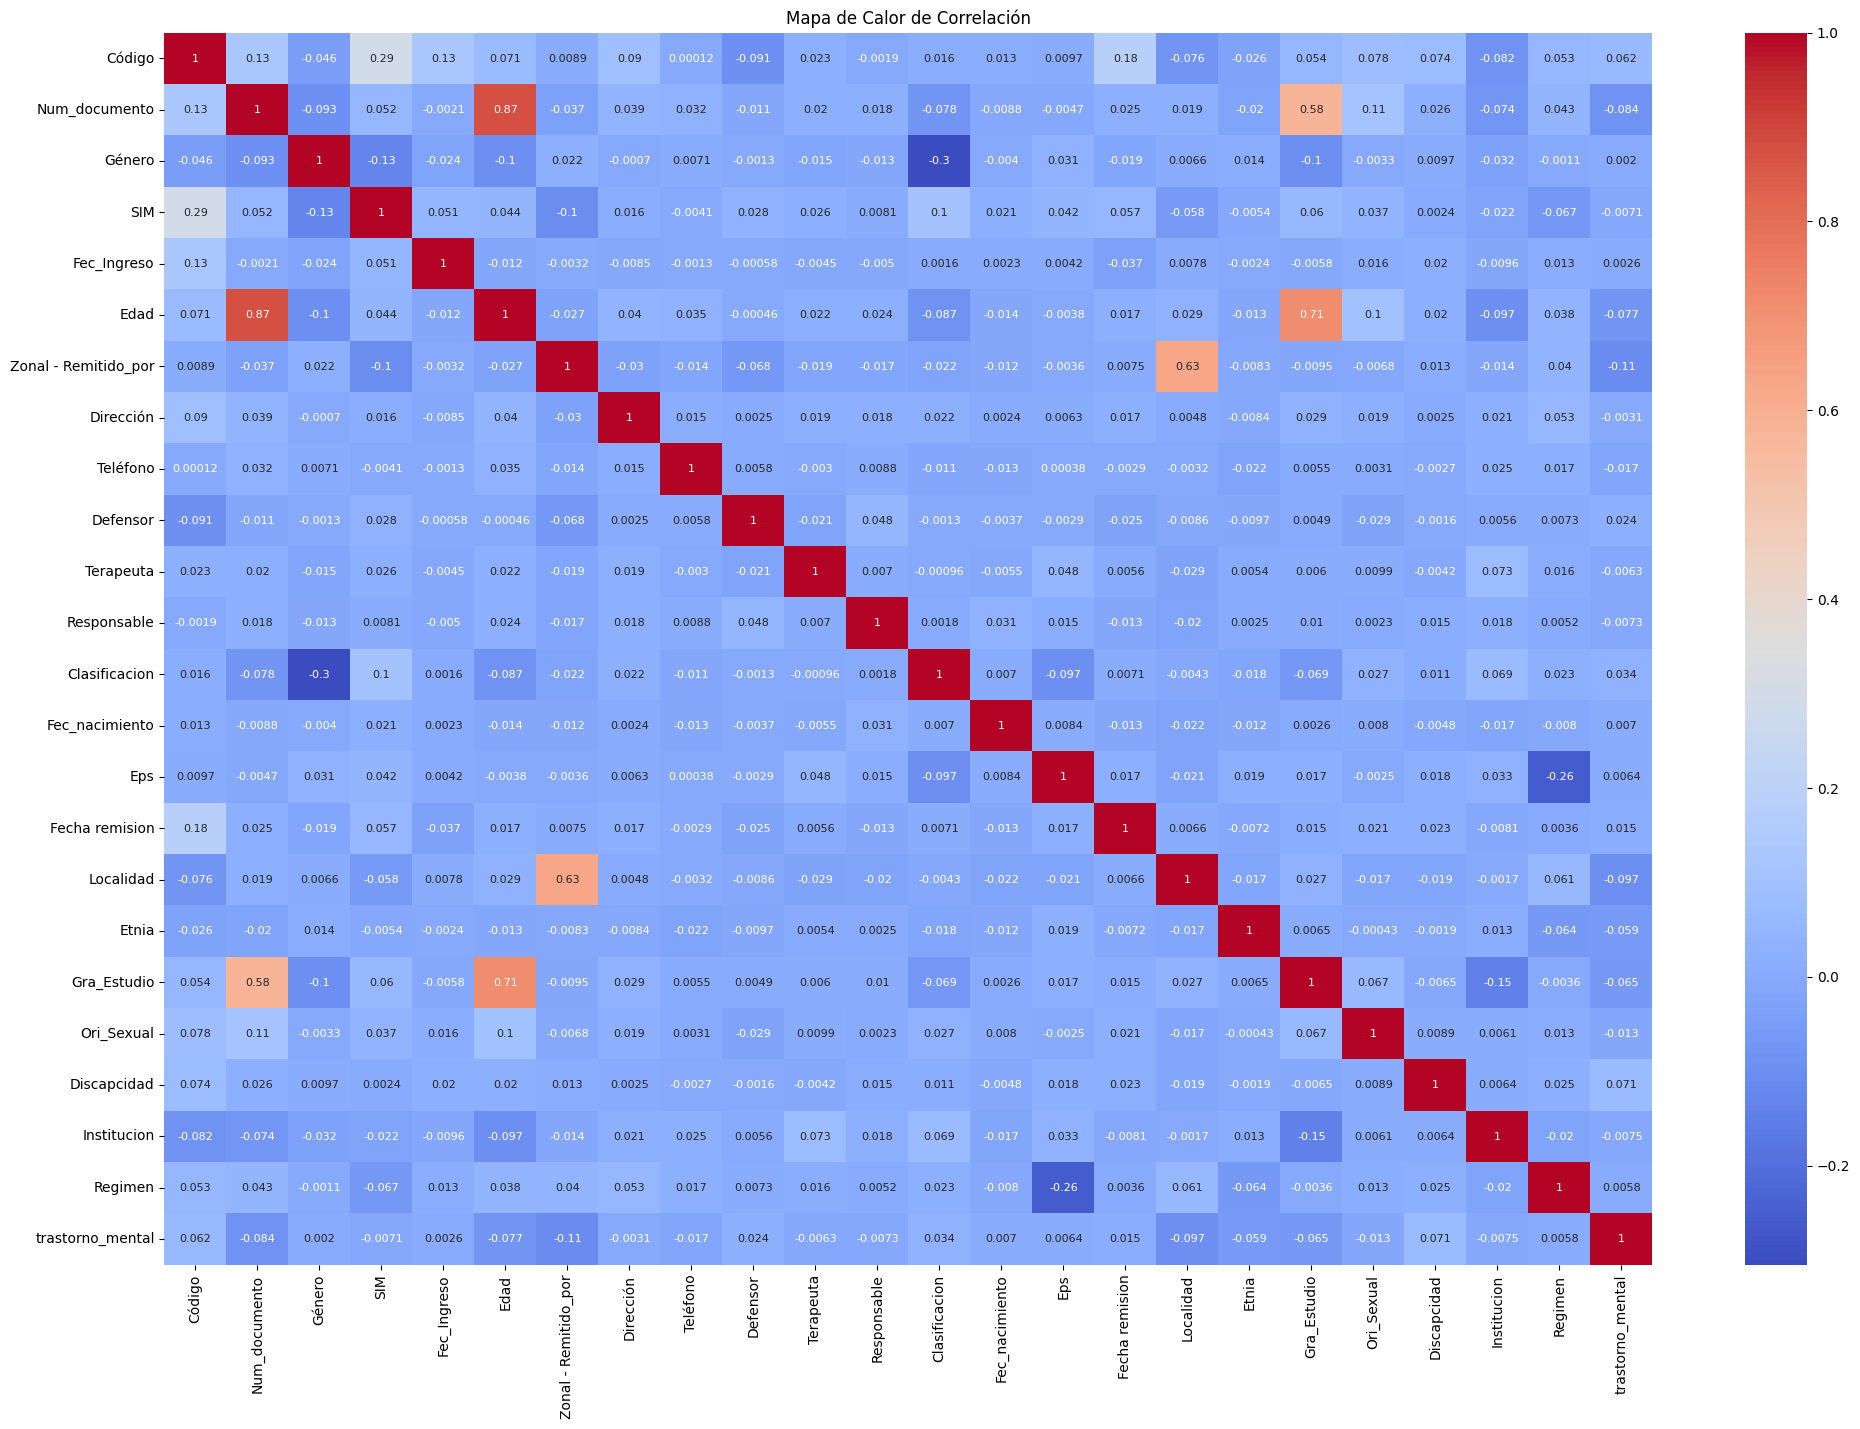

In [256]:
# Selecciona solo las columnas numéricas

df_encoded = df.copy()
df_encoded['trastorno_mental'] = df_encoded['trastorno_mental'].map({'Si': 1, 'No': 0})
categorical_cols = [col for col in df.select_dtypes(include=['object']).columns if col != 'trastorno_mental']

for column in categorical_cols:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])

correlation = df_encoded.corr()
plt.figure(figsize=(24, 16))
sns.heatmap(correlation, annot=True, cmap='coolwarm', annot_kws={"size": 8})
plt.title('Mapa de Calor de Correlación')
plt.show()


Instituciones (Orfanatos) donde viven la gran cantidad de niños que tienen positivo para enfermedades mentales

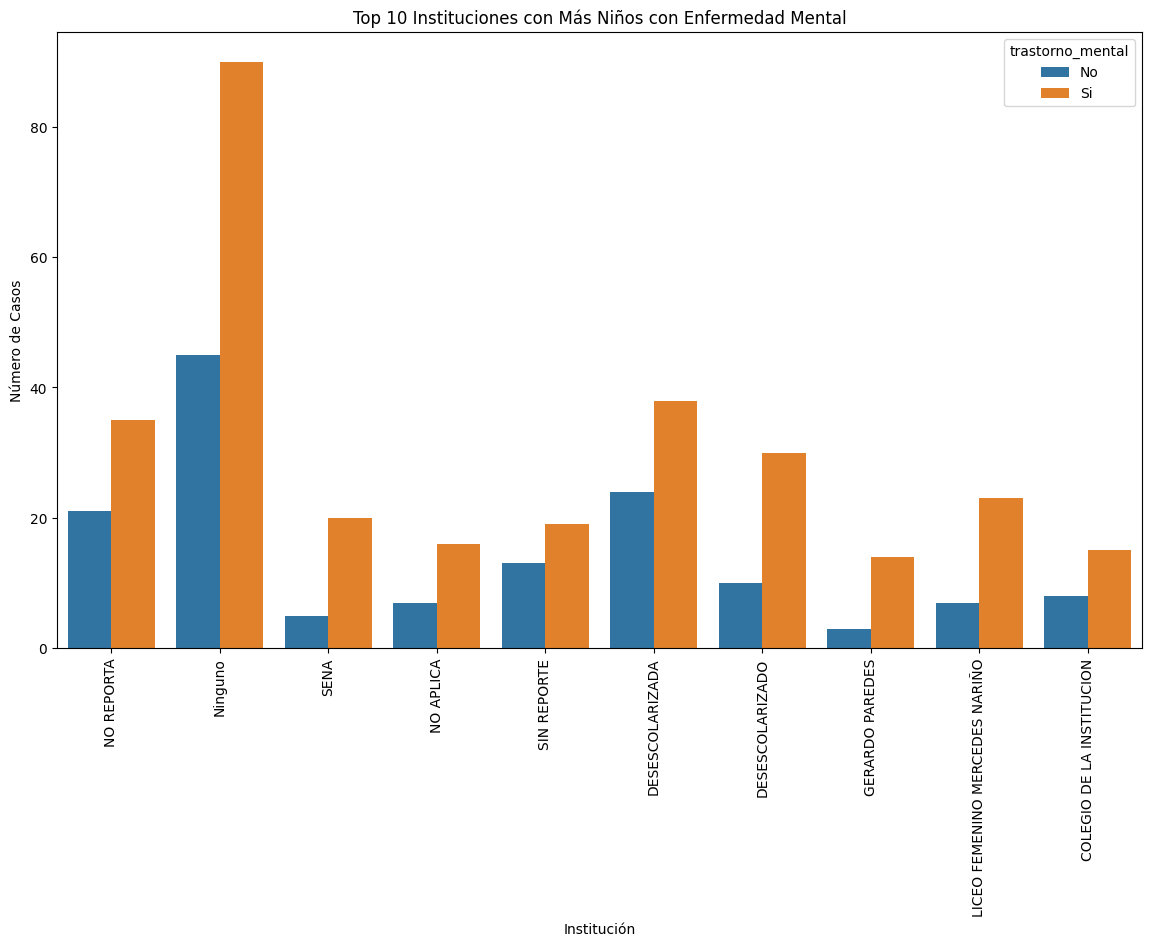

In [257]:
# Filtra el DataFrame para excluir "Ninguna" y obtener el top 10 de instituciones
top_institutions = df[(df['trastorno_mental'] == 'Si') & (df['Institucion'] != 'Ninguna')]['Institucion'].value_counts().nlargest(10).index

# Filtra el DataFrame para incluir solo las instituciones del top 10 (excluyendo "Ninguna")
df_top_institutions = df[(df['Institucion'].isin(top_institutions)) & (df['Institucion'] != 'Ninguna')]

# Genera el gráfico con el top 10 de instituciones
plt.figure(figsize=(14, 8))
sns.countplot(x='Institucion', hue='trastorno_mental', data=df_top_institutions)
plt.title('Top 10 Instituciones con Más Niños con Enfermedad Mental')
plt.xlabel('Institución')
plt.ylabel('Número de Casos')
plt.xticks(rotation=90)
plt.show()

##Reduccion de dimensionalidad (RFE)

---



En este paso vamos a escoger cuales son las caracteristicas especificas que podemos encontrar que pueden ser elegidas para el entrenamiento del modelo, esto mediante el modelo de Eliminación Recursiva de Características (RFE) porque es una técnica robusta y eficaz para seleccionar las características más relevantes de tu conjunto de datos.

In [ ]:
# Define las características "X" (excluyendo la columna de enfermedad_mental) y la columna de resultado "Y" o sea "enfermedad_mental"
X = df.drop(columns=['enfermedad_mental','Num_documento', 'SIM', 'Teléfono','Código', 'Responsable'])
y = df['enfermedad_mental']

In [ ]:
# Convierte columnas categóricas a valores numéricos mediante labelEncoder
for column in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])

In [ ]:
# Configura el modelo de clasificación vamos a utilizar randomforestClassifier
modelo = RandomForestClassifier()

# Configura el selector de características con RFE
selector = RFE(estimator=modelo, n_features_to_select=3, step=1)

# Ajusta el selector de características al conjunto de datos
selector = selector.fit(X, y)

# Selecciona las características más importantes
caracteristicas_seleccionadas = X.columns[selector.support_]

print("Características seleccionadas:", caracteristicas_seleccionadas)

Index(['Dirección', 'Fec_nacimiento', 'Institucion'], dtype='object')
Esas fueron las caracteristicas que respecto al algotimo deben ser las utilizadas

Direccion - Edad e Institucion pero haciendo pruebas el modelo mejora con la Localidad, por lo tanto, seran las utilizadas para entrenar al modelo y cumplir con la hipotesis generada al principio de este proyecto

In [ ]:
X = df[['Dirección', 'Edad','Localidad']]
y = df['enfermedad_mental']

# Convierte columnas categóricas a valores numéricos
for column in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])

# Divide el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Configura el modelo de clasificación
modelo = RandomForestClassifier()

# Ajusta el modelo al conjunto de entrenamiento
modelo.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evalúa el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
reporte = classification_report(y_test, y_pred)

print(f"Precisión: {accuracy}")
print("Reporte de Clasificación:")
print(reporte)

In [ ]:
# Genera la matriz de confusión
matriz_confusion = confusion_matrix(y_test, y_pred)

# Visualiza la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(matriz_confusion, annot=True, fmt="d", cmap="Blues", xticklabels=['No Enfermedad', 'Enfermedad'], yticklabels=['No Enfermedad', 'Enfermedad'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
# Define las características (X) y la columna de resultado (y)
X = df[['Dirección', 'Edad','Localidad']].copy()  # Añade .copy() para evitar SettingWithCopyWarning
y = df['enfermedad_mental']

# Preprocesamiento
categorical_features = ['Dirección','Localidad']
numerical_features = ['Edad']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ])

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', RandomForestClassifier(random_state=42))])

# Divide el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Ajusta el modelo al conjunto de entrenamiento
pipeline.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred = pipeline.predict(X_test)

# Evalúa el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
reporte = classification_report(y_test, y_pred)

print(f"Precisión: {accuracy}")
print("Reporte de Clasificación:")
print(reporte)

In [ ]:
# Genera la matriz de confusión
matriz_confusion = confusion_matrix(y_test, y_pred)

# Visualiza la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(matriz_confusion, annot=True, fmt="d", cmap="Blues", xticklabels=['No Enfermedad', 'Enfermedad'], yticklabels=['No Enfermedad', 'Enfermedad'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()